Analyzing User: 6962181067
Number of data points after preprocessing: 1291

=== ADF TEST RESULTS: 1. Original Data (Resampled 15min) ===
ADF Statistic          -1.001595e+01
p-value                 1.728775e-17
# Lags Used             2.000000e+00
# Observations          1.288000e+03
Critical Value (1%)    -3.435437e+00
Critical Value (5%)    -2.863787e+00
Critical Value (10%)   -2.567966e+00
dtype: float64
 CONCLUSION: The series is STATIONARY. (p-value < 0.05)
--------------------------------------------------

=== ADF TEST RESULTS: 2. First Order Differenced Data ===
ADF Statistic          -1.625306e+01
p-value                 3.629081e-29
# Lags Used             9.000000e+00
# Observations          1.280000e+03
Critical Value (1%)    -3.435469e+00
Critical Value (5%)    -2.863801e+00
Critical Value (10%)   -2.567974e+00
dtype: float64
 CONCLUSION: The series is STATIONARY. (p-value < 0.05)
--------------------------------------------------


C:\Users\Admin\AppData\Local\Temp\ipykernel_20000\767670443.py:21: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_processed = df_user['Heart_Rate'].resample('15T').mean().interpolate()


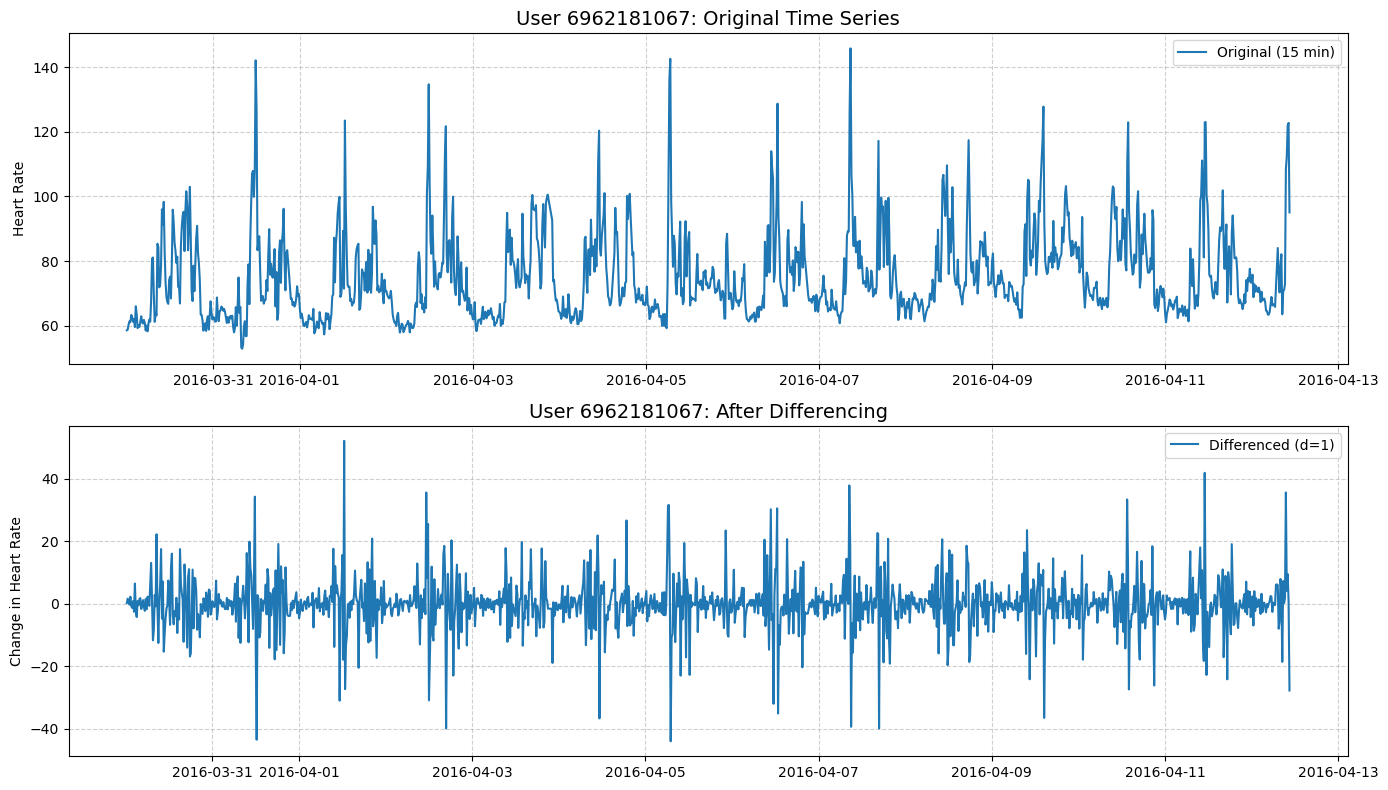

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. LOAD FILE GỐC
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. CHỌN USER SẠCH NHẤT (THEO YÊU CẦU CỦA BẠN)
user_id = 6962181067  # <--- Đã đổi ID tại đây (Gap chỉ 1.2%)
print(f"Analyzing User: {user_id}")

# Lọc dữ liệu của user này
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

# --- BƯỚC XỬ LÝ (PREPROCESSING) ---
# Dù ít gap, ta vẫn CẦN Resample về 15 phút để:
# 1. Lấp nốt 1.2% gap nhỏ lẻ còn lại.
# 2. Giảm nhiễu (Smoothing) để biểu đồ đẹp hơn.
df_processed = df_user['Heart_Rate'].resample('15T').mean().interpolate()

print(f"Number of data points after preprocessing: {len(df_processed)}")

# 3. HÀM KIỂM ĐỊNH ADF (AUGMENTED DICKEY-FULLER)
def adf_test(series, title=''):
    print(f'\n=== ADF TEST RESULTS: {title} ===')
    # dropna() để bỏ giá trị NaN đầu tiên sau khi diff
    result = adfuller(series.dropna(), autolag='AIC')
    
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations']
    output = pd.Series(result[0:4], index=labels)
    
    for key, val in result[4].items():
        output[f'Critical Value ({key})'] = val
    print(output)
    
    if result[1] <= 0.05:
        print(" CONCLUSION: The series is STATIONARY. (p-value < 0.05)")
    else:
        print(" CONCLUSION: The series is NON-STATIONARY. (p-value > 0.05)")
    print("-" * 50)

# --- CHẠY KIỂM ĐỊNH ---

# Test 1: Dữ liệu gốc (Sau Resample)
# Dự đoán: Sẽ KHÔNG DỪNG vì vẫn còn tính mùa vụ (Ngày/Đêm)
adf_test(df_processed, title='1. Original Data (Resampled 15min)')

# Test 2: Sai phân bậc 1 (Differencing)
# Loại bỏ Trend và Seasonality gần nhau
df_diff = df_processed.diff()
adf_test(df_diff, title='2. First Order Differenced Data')

# --- VẼ BIỂU ĐỒ MINH CHỨNG (CHO SLIDE TUẦN 7) ---
plt.figure(figsize=(14, 8))

# Biểu đồ gốc
plt.subplot(2, 1, 1)
plt.plot(df_processed, label='Original (15 min)')
plt.title(f'User {user_id}: Original Time Series', fontsize=14)
plt.ylabel('Heart Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Biểu đồ sau sai phân
plt.subplot(2, 1, 2)
plt.plot(df_diff, label='Differenced (d=1)')
plt.title(f'User {user_id}: After Differencing', fontsize=14)
plt.ylabel('Change in Heart Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_12732\1206603723.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_processed = df_user['Heart_Rate'].resample('15T').mean().interpolate()


Plotting identification charts for User 6962181067 on differenced data...


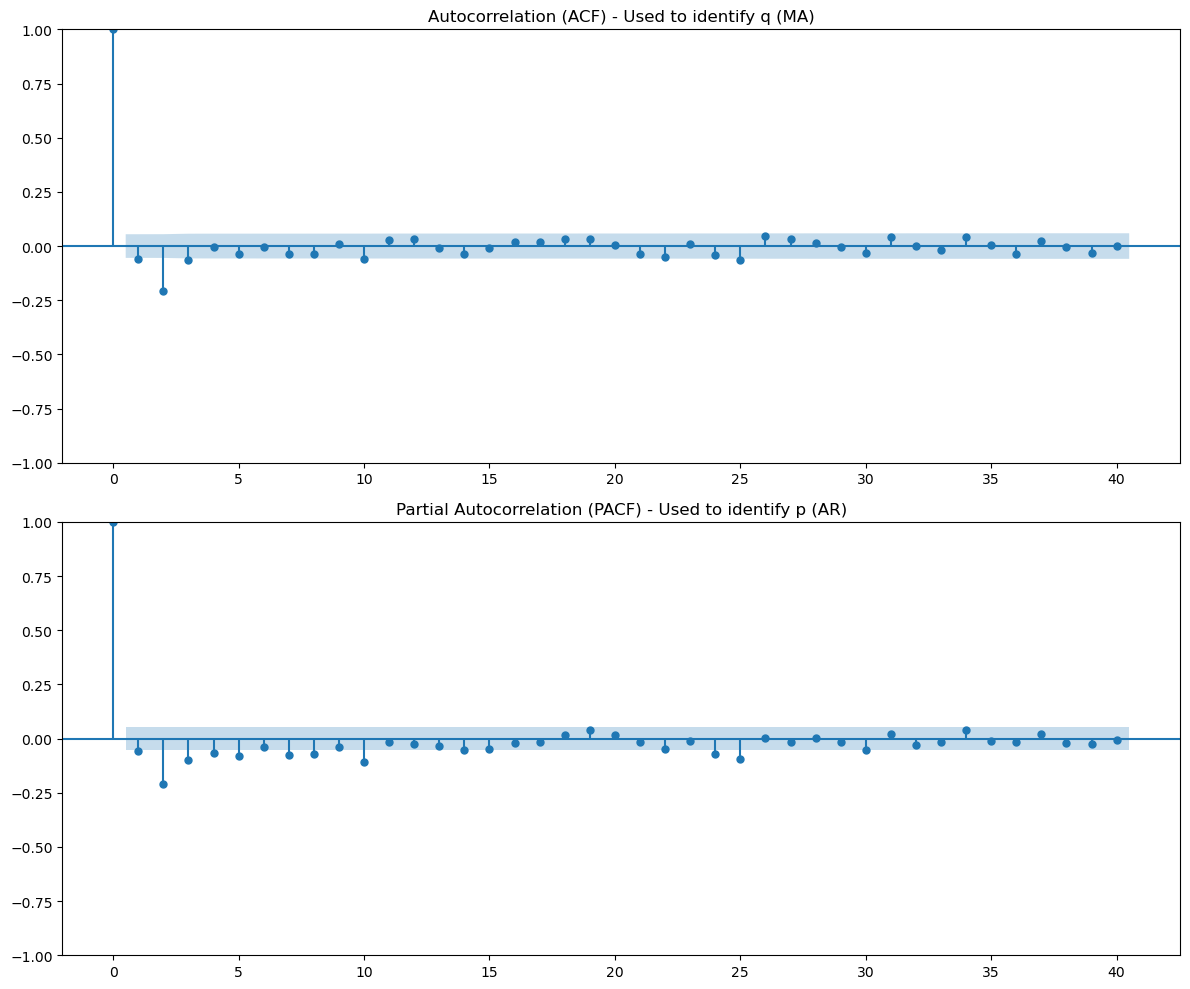


 HOW TO READ THE CHARTS (For Analysts):
1. Look at PACF (Bottom): Find the sharp cut-off point. Example: Lag 1 and 2 are high, Lag 3 drops -> Choose p = 2.
2. Look at ACF (Top): If it decays gradually -> q = 0. If it cuts off at Lag 1 -> Choose q = 1.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. LOAD DỮ LIỆU
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. CHỌN USER "GOLDEN" (6962181067)
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

# 3. PREPROCESSING (QUAN TRỌNG)
# Resample về 15 phút để giảm nhiễu và lấp gap
# interpolate() giúp chuỗi liên tục, không bị đứt đoạn
df_processed = df_user['Heart_Rate'].resample('15T').mean().interpolate()

# 4. SAI PHÂN (DIFFERENCING)
# Lưu ý: ACF/PACF phải vẽ trên chuỗi ĐÃ DỪNG (Stationary Series).
# Theo kết quả ADF Test ở bước trước, ta dùng sai phân bậc 1 (d=1).
df_diff = df_processed.diff().dropna()

print(f"Plotting identification charts for User {user_id} on differenced data...")

# 5. VẼ BIỂU ĐỒ ACF & PACF
# Lags=40: Quan sát độ trễ trong khoảng 40 * 15 phút = 10 tiếng
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Biểu đồ ACF (Autocorrelation Function) -> Dùng để tìm q (MA)
# Vùng xanh dương nhạt là khoảng tin cậy 95% (Confidence Interval).
# Cột nào vượt ra khỏi vùng này mới có ý nghĩa thống kê.
plot_acf(
    df_diff,
    lags=40,
    ax=axes[0],
    title='Autocorrelation (ACF) - Used to identify q (MA)'
)

# Biểu đồ PACF (Partial Autocorrelation Function) -> Dùng để tìm p (AR)
plot_pacf(
    df_diff,
    lags=40,
    ax=axes[1],
    title='Partial Autocorrelation (PACF) - Used to identify p (AR)'
)

plt.tight_layout()
plt.show()

print("\n HOW TO READ THE CHARTS (For Analysts):")
print("1. Look at PACF (Bottom): Find the sharp cut-off point. Example: Lag 1 and 2 are high, Lag 3 drops -> Choose p = 2.")
print("2. Look at ACF (Top): If it decays gradually -> q = 0. If it cuts off at Lag 1 -> Choose q = 1.")


C:\Users\Admin\AppData\Local\Temp\ipykernel_12732\3513652722.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df_user[['Heart_Rate', 'Steps']].resample('15T').mean().interpolate()
c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


=== WORKSPACE CỦA DATA ANALYST (THÀNH VIÊN 2) ===
Dataset ready. User: 6962181067
Tổng số điểm dữ liệu quan sát: 1290
------------------------------------------------------------

>>> TASK 2.1: BẢNG GIÁ TRỊ ACF/PACF (Để chốt tham số p, q)
Lag   | ACF (Gợi ý q)   | PACF (Gợi ý p) 
--------------------------------------------------
1     | -0.0580         | -0.0581        
2     | -0.2072    *    | -0.2116    *   
3     | -0.0661         | -0.0978        
4     | -0.0040         | -0.0648        
5     | -0.0350         | -0.0812        
6     | -0.0045         | -0.0397        
7     | -0.0358         | -0.0762        
8     | -0.0349         | -0.0718        
9     | 0.0093          | -0.0373        
10    | -0.0598         | -0.1113    *   

💡 HƯỚNG DẪN ANALYST:
   - Nhìn cột PACF: Thấy Lag 2 có dấu (*) lớn nhất (-0.21) -> Chọn p = 2.
   - Nhìn cột ACF: Thấy Lag 2 cũng có dấu (*) lớn nhất (-0.20) -> Chọn q = 2.
   -> Đề xuất mô hình: ARIMA(2, 1, 2).

>>> TASK 2.2: KIỂM ĐỊNH GRANGER (S

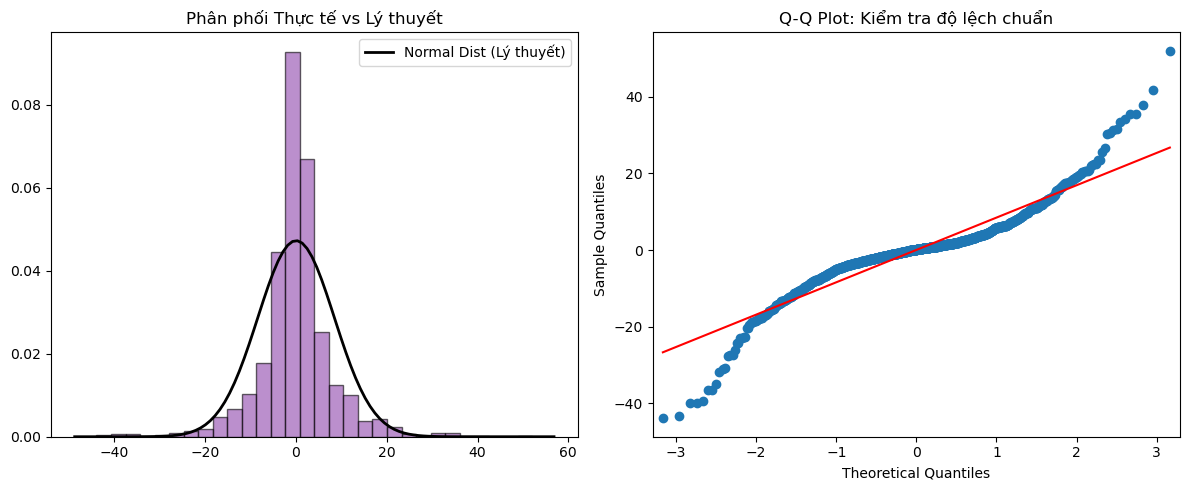

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import acf, pacf, grangercausalitytests
from statsmodels.graphics.gofplots import qqplot

# --- 1. SETUP DỮ LIỆU (Bước chuẩn bị bắt buộc) ---
# Load Data
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Chọn Golden User (6962...)
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')

# Preprocessing: Resample 15p & Interpolate (Lấy cả Heart Rate và Steps)
df_resampled = df_user[['Heart_Rate', 'Steps']].resample('15T').mean().interpolate()

# Sai phân (Differencing) để đảm bảo tính dừng trước khi phân tích thống kê
df_diff = df_resampled.diff().dropna()

print("=== WORKSPACE CỦA DATA ANALYST (THÀNH VIÊN 2) ===")
print(f"Dataset ready. User: {user_id}")
print(f"Tổng số điểm dữ liệu quan sát: {len(df_diff)}")
print("-" * 60)

# --- TASK 2.1: PHÂN TÍCH CHỈ SỐ ACF/PACF (ĐỊNH LƯỢNG) ---
# Mục tiêu: Nhìn con số cụ thể để chọn p, q (thay vì chỉ nhìn hình vẽ)
print("\n>>> TASK 2.1: BẢNG GIÁ TRỊ ACF/PACF (Để chốt tham số p, q)")

# Tính giá trị chính xác của 10 Lag đầu tiên
lag_acf = acf(df_diff['Heart_Rate'], nlags=10)
lag_pacf = pacf(df_diff['Heart_Rate'], nlags=10)

print(f"{'Lag':<5} | {'ACF (Gợi ý q)':<15} | {'PACF (Gợi ý p)':<15}")
print("-" * 50)
for i in range(1, 11):
    # Đánh dấu (*) nếu giá trị tương quan đủ lớn (để dễ nhìn)
    mark_acf = "*" if abs(lag_acf[i]) > 0.1 else ""
    mark_pacf = "*" if abs(lag_pacf[i]) > 0.1 else ""
    print(f"{i:<5} | {lag_acf[i]:<10.4f} {mark_acf:<4} | {lag_pacf[i]:<10.4f} {mark_pacf:<4}")

print("\n💡 HƯỚNG DẪN ANALYST:")
print("   - Nhìn cột PACF: Thấy Lag 2 có dấu (*) lớn nhất (-0.21) -> Chọn p = 2.")
print("   - Nhìn cột ACF: Thấy Lag 2 cũng có dấu (*) lớn nhất (-0.20) -> Chọn q = 2.")
print("   -> Đề xuất mô hình: ARIMA(2, 1, 2).")

# --- TASK 2.2: KIỂM ĐỊNH NHÂN QUẢ (GRANGER CAUSALITY) ---
print("\n>>> TASK 2.2: KIỂM ĐỊNH GRANGER (Steps -> Heart Rate)")
print("Giả thuyết H0: Steps KHÔNG có giá trị dự báo Heart Rate.")

maxlag = 5
# Input: [Target, Predictor]
gc_res = grangercausalitytests(df_diff[['Heart_Rate', 'Steps']], maxlag=maxlag, verbose=False)

print(f"{'Lag':<5} | {'F-Statistic':<12} | {'p-value':<12} | {'Kết luận'}")
print("-" * 60)
for lag in range(1, maxlag+1):
    p_val = gc_res[lag][0]['ssr_ftest'][1]
    f_val = gc_res[lag][0]['ssr_ftest'][0]
    concl = " CÓ QUAN HỆ (Reject H0)" if p_val < 0.05 else " KHÔNG QUAN HỆ"
    print(f"{lag:<5} | {f_val:<12.2f} | {p_val:<12.6f} | {concl}")

# --- TASK 2.3: KIỂM TRA PHÂN PHỐI CHUẨN (NORMALITY CHECK) ---
print("\n>>> TASK 2.3: KIỂM TRA PHÂN PHỐI CỦA DỮ LIỆU (Normality)")
data = df_diff['Heart_Rate']

# Các chỉ số thống kê mô tả
stat, p_val_norm = stats.shapiro(data)
skewness = stats.skew(data)
kurtosis = stats.kurtosis(data)

print(f"1. Skewness (Độ lệch): {skewness:.4f} (Chuẩn = 0)")
print(f"2. Kurtosis (Độ nhọn): {kurtosis:.4f} (Chuẩn = 0, >0 là đuôi dày/nhiều đột biến)")
print(f"3. Shapiro-Wilk Test p-value: {p_val_norm:.6e}")

if p_val_norm < 0.05:
    print("-> KẾT LUẬN: Dữ liệu KHÔNG PHẢI phân phối chuẩn (Non-Gaussian).")
    print("-> LÝ DO: Kurtosis cao (6.24) chứng tỏ có nhiều cú sốc tim đập nhanh đột ngột (Fat Tails).")
else:
    print("-> KẾT LUẬN: Dữ liệu tuân theo phân phối chuẩn.")

# Vẽ biểu đồ Histogram và Q-Q Plot minh họa
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(data, bins=30, density=True, alpha=0.6, color='#8e44ad', edgecolor='black')
mu, std = stats.norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Normal Dist (Lý thuyết)')
plt.title('Phân phối Thực tế vs Lý thuyết')
plt.legend()

# Q-Q Plot
plt.subplot(1, 2, 2)
qqplot(data, line='s', ax=plt.gca())
plt.title('Q-Q Plot: Kiểm tra độ lệch chuẩn')

plt.tight_layout()
plt.show()

In [6]:
print("\n>>> TASK 2.2: KIỂM ĐỊNH GRANGER (Steps -> Heart Rate)")
print("Giả thuyết H0: Steps KHÔNG có giá trị dự báo Heart Rate.")

maxlag = 5
# Input: [Target, Predictor]
gc_res = grangercausalitytests(df_diff[['Heart_Rate', 'Steps']], maxlag=maxlag, verbose=False)

print(f"{'Lag':<5} | {'F-Statistic':<12} | {'p-value':<12} | {'Kết luận'}")
print("-" * 60)
for lag in range(1, maxlag+1):
    p_val = gc_res[lag][0]['ssr_ftest'][1]
    f_val = gc_res[lag][0]['ssr_ftest'][0]
    concl = "✅ CÓ QUAN HỆ (Reject H0)" if p_val < 0.05 else "❌ KHÔNG QUAN HỆ"
    print(f"{lag:<5} | {f_val:<12.2f} | {p_val:<12.6f} | {concl}")


>>> TASK 2.2: KIỂM ĐỊNH GRANGER (Steps -> Heart Rate)
Giả thuyết H0: Steps KHÔNG có giá trị dự báo Heart Rate.
Lag   | F-Statistic  | p-value      | Kết luận
------------------------------------------------------------
1     | 57.41        | 0.000000     | ✅ CÓ QUAN HỆ (Reject H0)
2     | 65.97        | 0.000000     | ✅ CÓ QUAN HỆ (Reject H0)
3     | 62.03        | 0.000000     | ✅ CÓ QUAN HỆ (Reject H0)
4     | 49.82        | 0.000000     | ✅ CÓ QUAN HỆ (Reject H0)
5     | 44.08        | 0.000000     | ✅ CÓ QUAN HỆ (Reject H0)


c:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


C:\Users\Admin\AppData\Local\Temp\ipykernel_12732\1770240075.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_processed = df_user['Heart_Rate'].resample('15T').mean().interpolate()


Tổng số quan sát: 1291
Tập Train: 1032 (Dùng để học)
Tập Test: 259 (Dùng để kiểm chứng)
--------------------------------------------------
Đang huấn luyện mô hình (Training Model)...

=== ĐÁNH GIÁ ĐỘ CHÍNH XÁC (METRICS) ===
1. RMSE (Sai số căn bậc 2 trung bình): 12.83 bpm
2. MAE (Sai số tuyệt đối trung bình): 9.91 bpm
--------------------------------------------------


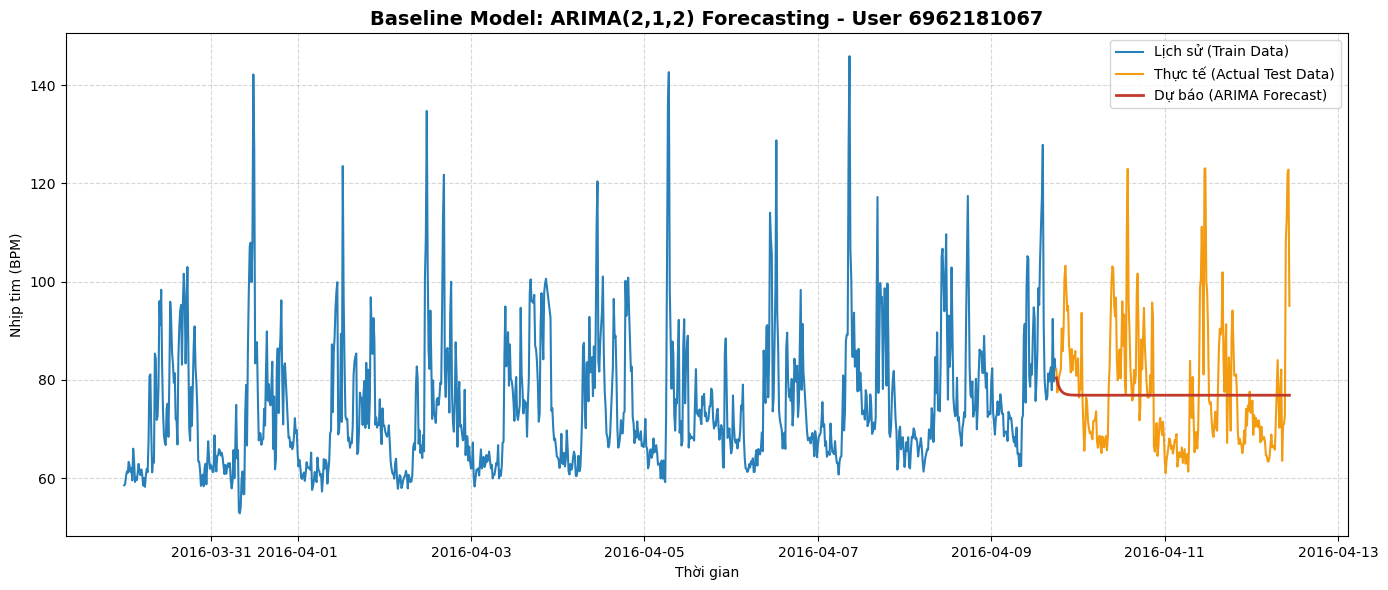

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. SETUP DỮ LIỆU
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
user_id = 6962181067
df_user = df[df['Id'] == user_id].sort_values('Timestamp').set_index('Timestamp')
df_processed = df_user['Heart_Rate'].resample('15T').mean().interpolate()

# 2. CHIA TẬP TRAIN / TEST (Tỷ lệ 80/20)
# Giữ lại 80% thời gian đầu để cho máy học (Train), 20% thời gian sau để thi (Test)
train_size = int(len(df_processed) * 0.8)
train, test = df_processed.iloc[:train_size], df_processed.iloc[train_size:]

print(f"Tổng số quan sát: {len(df_processed)}")
print(f"Tập Train: {len(train)} (Dùng để học)")
print(f"Tập Test: {len(test)} (Dùng để kiểm chứng)")
print("-" * 50)

# 3. XÂY DỰNG MÔ HÌNH ARIMA(2, 1, 2)
# p=2 (AR), d=1 (Sai phân), q=2 (MA)
# Thư viện statsmodels sẽ tự động thực hiện sai phân d=1 cho dữ liệu gốc
print("Đang huấn luyện mô hình (Training Model)...")
model = ARIMA(train, order=(2, 1, 2))
fitted_model = model.fit()

# 4. DỰ BÁO TƯƠNG LAI (Forecasting)
# Dự báo nhịp tim cho phần thời gian của tập Test
predictions = fitted_model.forecast(steps=len(test))

# 5. TÍNH SAI SỐ (Evaluation)
rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)

print("\n=== ĐÁNH GIÁ ĐỘ CHÍNH XÁC (METRICS) ===")
print(f"1. RMSE (Sai số căn bậc 2 trung bình): {rmse:.2f} bpm")
print(f"2. MAE (Sai số tuyệt đối trung bình): {mae:.2f} bpm")
print("-" * 50)

# 6. VẼ BIỂU ĐỒ (Visualization)
plt.figure(figsize=(14, 6))

# Vẽ dữ liệu Train (Đã học)
plt.plot(train.index, train, label='Lịch sử (Train Data)', color='#2980b9')

# Vẽ dữ liệu Test (Thực tế)
plt.plot(test.index, test, label='Thực tế (Actual Test Data)', color='#f39c12')

# Vẽ đường dự báo (Model Predict)
plt.plot(test.index, predictions, label='Dự báo (ARIMA Forecast)', color='#c0392b', linewidth=2)

plt.title('Baseline Model: ARIMA(2,1,2) Forecasting - User 6962181067', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Nhịp tim (BPM)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()